In [1]:
# SECTION A-
# 1. Explain why NumPy vectorisation is a technically superior approach to the for-loop
# suggestion. In your answer, describe what broadcasting allows when a single scalar fee rate
# (e.g., Rs 5 per km) is applied to the entire array, and identify one scenario where a Python loop
#  would still be necessary despite NumPy being available.


import numpy as np

distances = np.random.randint(1, 20, 50000)

fee_rate = 5   

delivery_fee = distances * fee_rate

print("Number of orders:", len(distances))
print("First 10 distances:", distances[:10])
print("First 10 delivery fees:", delivery_fee[:10])

Number of orders: 50000
First 10 distances: [18 16 16  2 12 15 10 16 17 12]
First 10 delivery fees: [90 80 80 10 60 75 50 80 85 60]


In [2]:
# 2.Explain why groupby() combined with agg() is the correct approach instead of the
#   for-loop strategy. Describe the specific method chain you would write to compute average order
#   value, average delivery time, and average rating per restaurant in a single operation, and
#   explain what the resulting DataFrame's index represents after the operation

import pandas as pd

df = pd.DataFrame({
    "order_id": [1, 2, 3, 4, 5, 6],
    "restaurant_name": ["A", "A", "B", "B", "C", "C"],
    "city": ["Mumbai", "Mumbai", "Pune", "Pune", "Delhi", "Delhi"],
    "order_value": [200, 300, 150, 250, 400, 500],
    "delivery_time_mins": [30, 40, 25, 35, 45, 50],
    "rating": [4, 5, 3, 4, 5, 4]
})

result = df.groupby("restaurant_name").agg({
    "order_value": "mean",
    "delivery_time_mins": "mean",
    "rating": "mean"
})

print(result)

                 order_value  delivery_time_mins  rating
restaurant_name                                         
A                      250.0                35.0     4.5
B                      200.0                30.0     3.5
C                      450.0                47.5     4.5


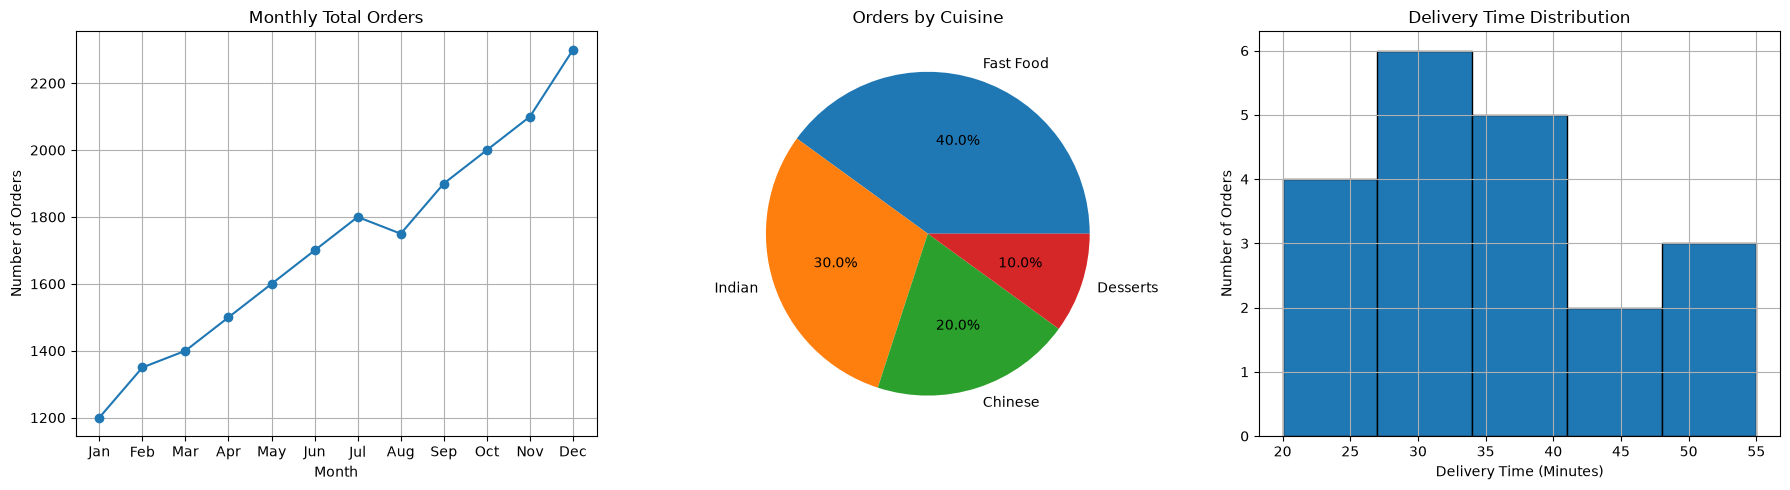

In [4]:
# 3. Describe how you would use plt.annotate() to programmatically identify and mark
#   the maximum order day with an arrow pointing to the peak and a text label showing the day
#   number and volume. Name at least two specific parameters you would pass to plt.annotate()
#   and explain what each one controls in the rendered chart.

import matplotlib.pyplot as plt

months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun",
          "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

orders = [1200, 1350, 1400, 1500, 1600, 1700,
          1800, 1750, 1900, 2000, 2100, 2300]

cuisines = ["Fast Food", "Indian", "Chinese", "Desserts"]
cuisine_orders = [40, 30, 20, 10]

delivery_times = [20, 25, 30, 35, 40, 28, 32, 45, 50,
                  22, 27, 31, 36, 42, 48, 55, 25, 30, 38, 40]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(months, orders, marker="o")
axes[0].set_title("Monthly Total Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Number of Orders")
axes[0].grid(True)

axes[1].pie(cuisine_orders, labels=cuisines, autopct="%1.1f%%")
axes[1].set_title("Orders by Cuisine")

axes[2].hist(delivery_times, bins=5, edgecolor="black")
axes[2].set_title("Delivery Time Distribution")
axes[2].set_xlabel("Delivery Time (Minutes)")
axes[2].set_ylabel("Number of Orders")
axes[2].grid(True)

plt.tight_layout()
plt.show()

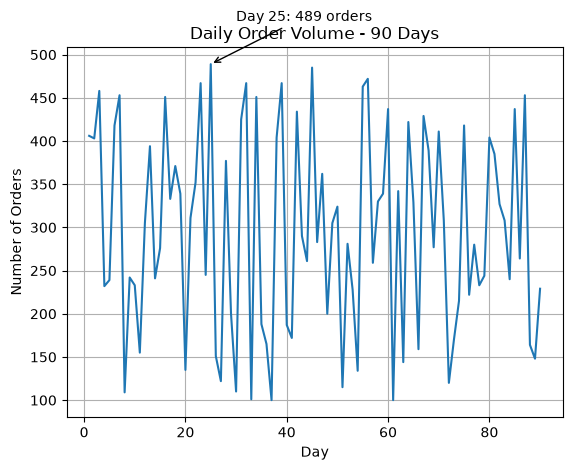

In [5]:
# 4.Describe how you would use plt.annotate() to programmatically identify and mark
#  the maximum order day with an arrow pointing to the peak and a text label showing the day
#  number and volume. Name at least two specific parameters you would pass to plt.annotate()
#  and explain what each one controls in the rendered chart.

import matplotlib.pyplot as plt
import numpy as np

days = np.arange(1, 91)

orders = np.random.randint(100, 500, 90)

max_index = np.argmax(orders)
max_day = days[max_index]
max_orders = orders[max_index]

plt.plot(days, orders)

plt.annotate(
    f"Day {max_day}: {max_orders} orders",
    xy=(max_day, max_orders),
    xytext=(max_day + 5, max_orders + 50),
    arrowprops=dict(arrowstyle="->")
)

plt.xlabel("Day")
plt.ylabel("Number of Orders")
plt.title("Daily Order Volume - 90 Days")
plt.grid(True)

plt.show()

    category  rating
0     Casual       2
1  Fast Food       2
2     Casual       4
3     Casual       1
4  Fast Food       2


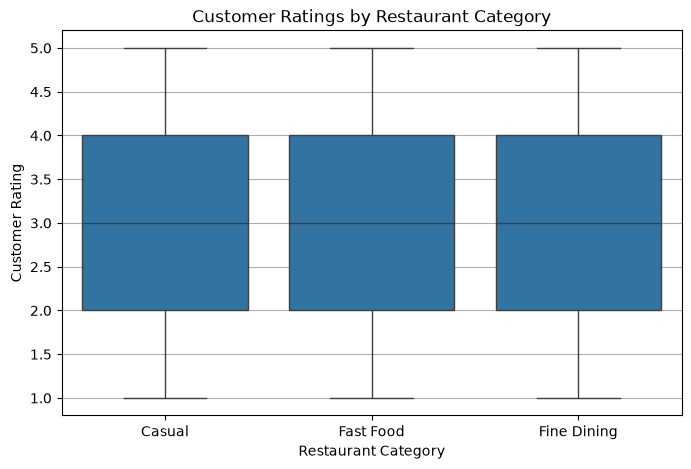

In [6]:
# 5.Compare sns.boxplot() and sns.violinplot() for this specific task. Which would you
#  recommend and why? Provide at least two data-specific reasons that reference properties of
#  this dataset (10,000 rows, 3 categories, discrete 1–5 scale), and explain one situation where the
#  other chart type would be preferable.

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

categories = np.random.choice(
    ["Fast Food", "Fine Dining", "Casual"],
    size=10000
)

ratings = np.random.choice(
    [1, 2, 3, 4, 5],
    size=10000
)

df = pd.DataFrame({
    "category": categories,
    "rating": ratings
})

print(df.head())

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="category",
    y="rating"
)

plt.xlabel("Restaurant Category")
plt.ylabel("Customer Rating")
plt.title("Customer Ratings by Restaurant Category")
plt.grid(axis="y")

plt.show()

Column names:
['category', 'rating']

First 5 rows:
    category  rating
0     Casual       2
1  Fast Food       2
2     Casual       4
3     Casual       1
4  Fast Food       2

Numeric columns:
['rating']

Correlation Matrix:
        rating
rating     1.0


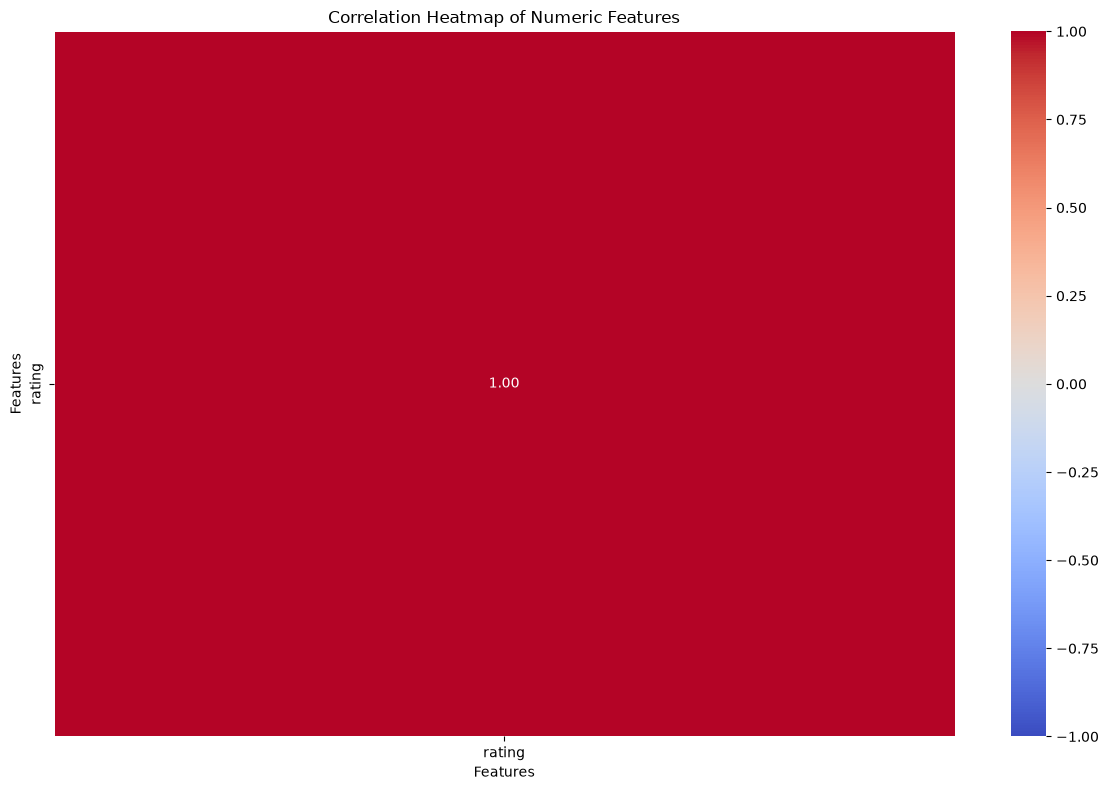


Potential Multicollinearity (|correlation| >= 0.80):
Empty DataFrame
Columns: []
Index: []


In [8]:
# 6.

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Column names:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

numeric_df = df.select_dtypes(include="number")

print("\nNumeric columns:")
print(numeric_df.columns.tolist())

corr = numeric_df.corr()

print("\nCorrelation Matrix:")
print(corr)

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap of Numeric Features")
plt.xlabel("Features")
plt.ylabel("Features")

plt.tight_layout()
plt.show()

high_corr = corr.where(
    (abs(corr) >= 0.80) & (abs(corr) < 1.00)
)

print("\nPotential Multicollinearity (|correlation| >= 0.80):")
print(high_corr.dropna(how="all").dropna(axis=1, how="all"))

In [9]:
# SECTION B :-

# 1. TASK 1

import numpy as np

np.random.seed(42)

distances = np.random.uniform(1.0, 15.0, 25)

fees = 20 + 5 * distances

print("Delivery Distances:")
print(distances)

print("\nDelivery Fees:")
print(fees)

condition = fees > 60

qualifying_distances = distances[condition]
qualifying_fees = fees[condition]

print("\nOrders where delivery fee exceeds Rs 60:")
print("Distance (km)    Fee (Rs)")

for distance, fee in zip(qualifying_distances, qualifying_fees):
    print(f"{distance:.2f}           {fee:.2f}")

print("\nFee Statistics:")
print("Minimum Fee:", np.min(fees))
print("Maximum Fee:", np.max(fees))
print("Mean Fee:", np.mean(fees))
print("Standard Deviation:", np.std(fees))

Delivery Distances:
[ 6.24356166 14.31000029 11.24791519  9.38121878  3.18426097  3.18392328
  1.81317057 13.12646604  9.41561016 10.91301609  1.28818292 14.57873793
 12.65419697  3.97274755  3.54554954  3.56766314  5.2593914   8.34659004
  7.04723026  5.07720796  9.56594053  2.95291405  5.09002508  6.12906581
  7.38497978]

Delivery Fees:
[51.21780832 91.55000145 76.23957593 66.90609389 35.92130483 35.91961642
 29.06585285 85.6323302  67.07805082 74.56508045 26.4409146  92.89368965
 83.27098486 39.86373775 37.7277477  37.83831569 46.29695701 61.73295021
 55.2361513  45.38603981 67.82970263 34.76457025 45.4501254  50.64532903
 56.9248989 ]

Orders where delivery fee exceeds Rs 60:
Distance (km)    Fee (Rs)
14.31           91.55
11.25           76.24
9.38           66.91
13.13           85.63
9.42           67.08
10.91           74.57
14.58           92.89
12.65           83.27
8.35           61.73
9.57           67.83

Fee Statistics:
Minimum Fee: 26.440914600706172
Maximum Fee: 92.893

In [10]:
# TASK 2-

import pandas as pd
import numpy as np

np.random.seed(42)

restaurants = ["Food Hub","Spice Villa","Tasty Treat","Urban Bites","Royal Kitchen"]

cities = ["Vadodara","Ahmedabad","Surat"]

cuisines = ["Indian","Chinese","Fast Food"]

df = pd.DataFrame({
    "restaurant_name": np.random.choice(restaurants, 40),
    "city": np.random.choice(cities, 40),
    "order_value": np.random.randint(200, 1001, 40),
    "delivery_time_mins": np.random.randint(20, 46, 40),
    "rating": np.round(np.random.uniform(3.5, 5.0, 40), 1),
    "cuisine_type": np.random.choice(cuisines, 40)
})

print("Food Delivery Dataset:")
print(df)

result = (
    df.groupby("restaurant_name")
      .agg(
          mean_order_value=("order_value", "mean"),
          mean_delivery_time=("delivery_time_mins", "mean"),
          mean_rating=("rating", "mean")
      )
      .query("mean_rating > 4.0 and mean_delivery_time < 35")
      .sort_values("mean_order_value", ascending=False)
      .reset_index()
)

print("\nRestaurant Performance Summary:")
print(result.to_string(index=False))

Food Delivery Dataset:
   restaurant_name       city  order_value  delivery_time_mins  rating  \
0      Urban Bites   Vadodara          252                  31     4.7   
1    Royal Kitchen  Ahmedabad          991                  27     4.5   
2      Tasty Treat  Ahmedabad          416                  41     4.8   
3    Royal Kitchen  Ahmedabad          963                  22     4.7   
4    Royal Kitchen   Vadodara          387                  20     3.8   
5      Spice Villa  Ahmedabad          579                  22     4.8   
6      Tasty Treat   Vadodara          692                  24     4.3   
7      Tasty Treat  Ahmedabad          240                  34     4.7   
8      Tasty Treat      Surat          356                  33     4.8   
9    Royal Kitchen      Surat          214                  22     4.0   
10     Urban Bites   Vadodara          264                  20     3.7   
11     Tasty Treat      Surat          720                  24     3.8   
12   Royal Kitc

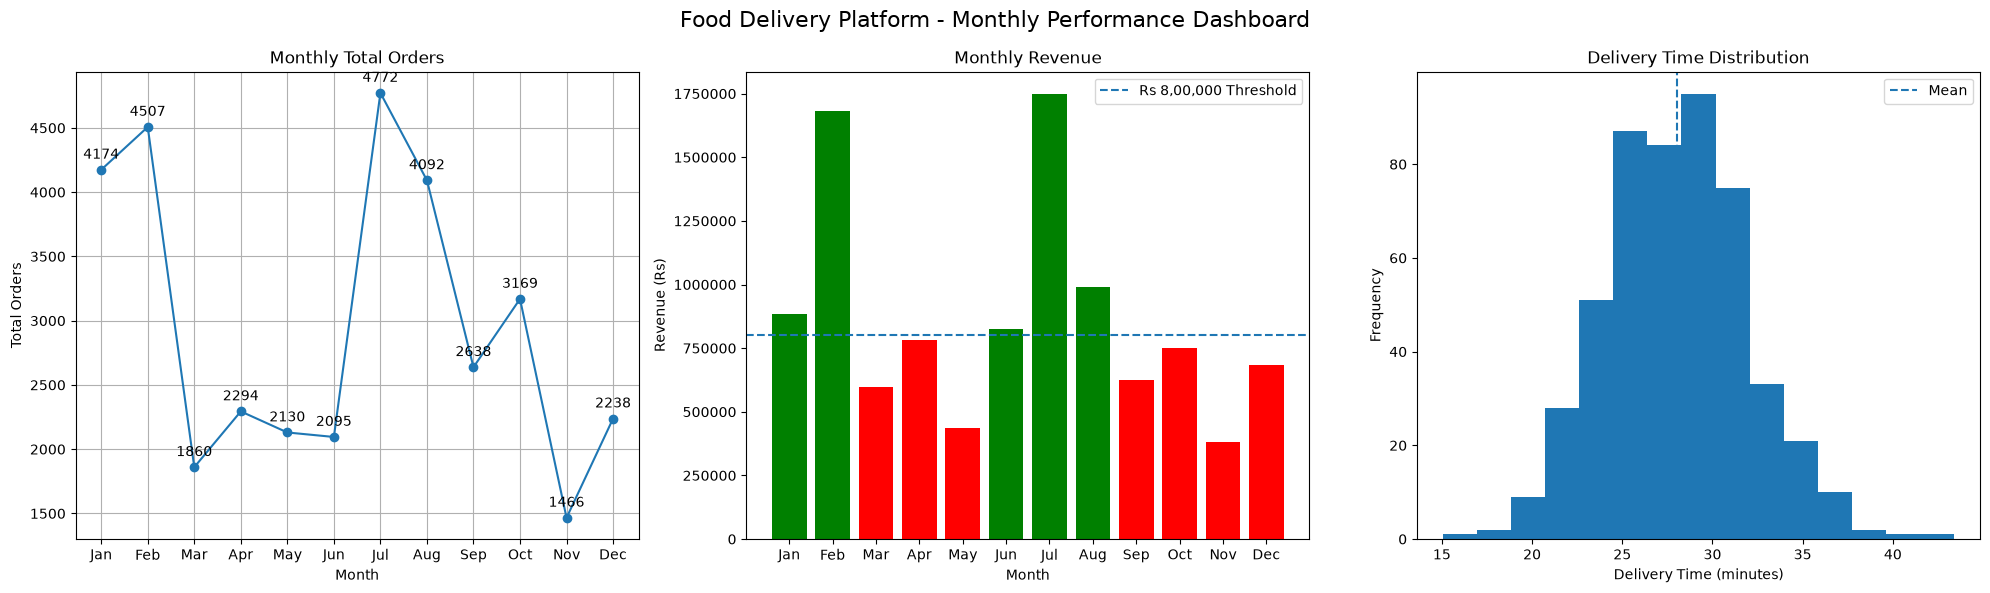

Dashboard saved as food_delivery_dashboard.png


In [11]:
# TASK 3-

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

orders = np.random.randint(1000, 5001, 12)

average_order_value = np.random.uniform(200, 400, 12)

revenue = orders * average_order_value

delivery_time = np.random.normal(28, 4, 12)

delivery_times_500 = np.random.normal(28, 4, 500)

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

fig.suptitle(
    "Food Delivery Platform - Monthly Performance Dashboard",
    fontsize=16
)

axes[0].plot(
    months,
    orders,
    marker="o"
)

axes[0].set_title("Monthly Total Orders")
axes[0].set_xlabel("Month")
axes[0].set_ylabel("Total Orders")
axes[0].grid(True)

for i, value in enumerate(orders):
    axes[0].annotate(
        str(value),
        (i, value),
        xytext=(0, 8),
        textcoords="offset points",
        ha="center"
    )

threshold = 800000

bar_colors = np.where(revenue > threshold, "green", "red")

axes[1].bar(
    months,
    revenue,
    color=bar_colors
)

axes[1].axhline(
    threshold,
    linestyle="--",
    label="Rs 8,00,000 Threshold"
)

axes[1].set_title("Monthly Revenue")
axes[1].set_xlabel("Month")
axes[1].set_ylabel("Revenue (Rs)")
axes[1].legend()
axes[1].ticklabel_format(axis="y", style="plain")

axes[2].hist(
    delivery_times_500,
    bins=15
)

sample_mean = np.mean(delivery_times_500)

axes[2].axvline(
    sample_mean,
    linestyle="--",
    label="Mean"
)

axes[2].set_title("Delivery Time Distribution")
axes[2].set_xlabel("Delivery Time (minutes)")
axes[2].set_ylabel("Frequency")
axes[2].legend()

plt.tight_layout()

plt.savefig(
    "food_delivery_dashboard.png",
    dpi=150
)
plt.show()
print("Dashboard saved as food_delivery_dashboard.png")

Original Dataset:
   order_value  distance_km  delivery_time_mins    rating  discount_pct
0   153.415803    15.287118           29.436359  1.610398     17.079069
1   645.943155     2.171641           41.143419  1.247733      4.256927
2   406.886462    15.151650           20.002291  3.285994     18.347489
3   606.425624    18.979243           18.019293  1.749068     29.233717
4   784.592658    12.467631           24.767687  3.171931      8.202608

Dataset Shape:
(200, 5)

Null Values Before Cleaning:
order_value            0
distance_km            0
delivery_time_mins    10
rating                10
discount_pct           0
dtype: int64

Null Values After Cleaning:
order_value           0
distance_km           0
delivery_time_mins    0
rating                0
discount_pct          0
dtype: int64

Final Dataset:
   order_value  distance_km  delivery_time_mins    rating  discount_pct  \
0   153.415803    15.287118           29.436359  1.610398     17.079069   
1   645.943155     2.171641  

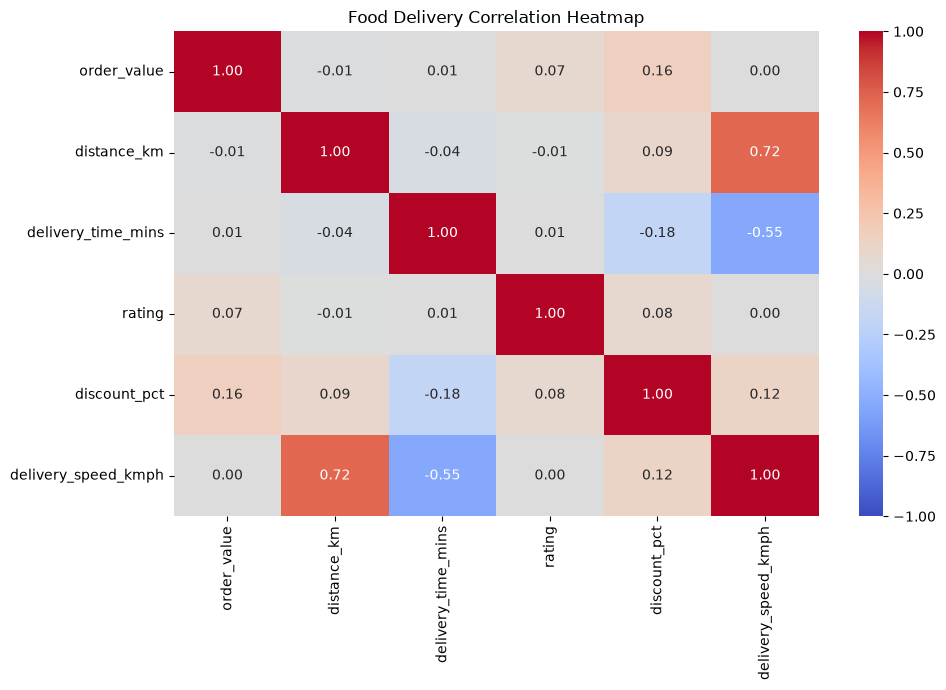

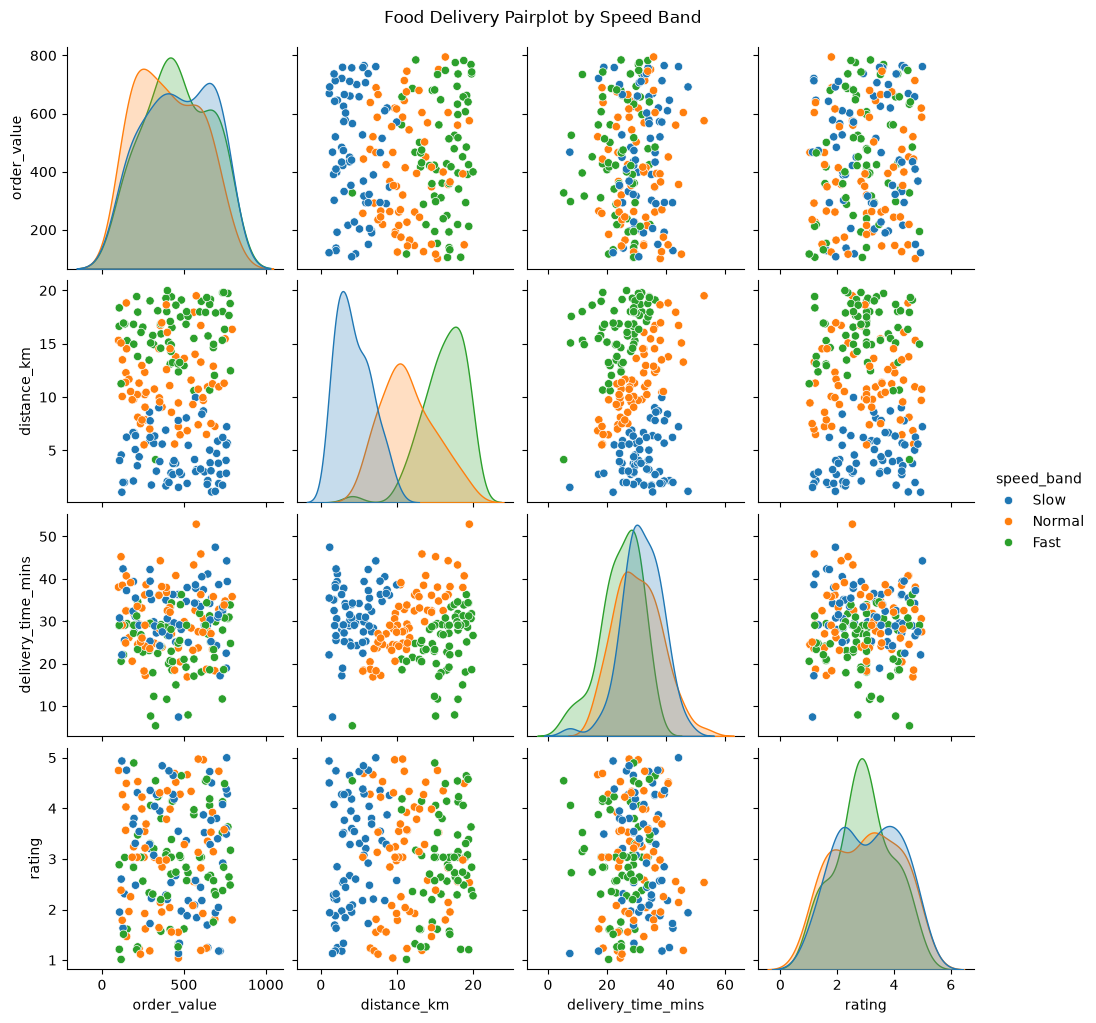


Analysis Completed Successfully!

Files Saved:
1. correlation_heatmap.png
2. pairplot.png


In [12]:
# TASK 4-

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(7)

n = 200

order_value = np.random.uniform(100, 800, n)

distance_km = np.random.uniform(1, 20, n)

delivery_time_mins = np.random.normal(30, 8, n)

rating = np.random.uniform(1.0, 5.0, n)

discount_pct = np.random.uniform(0, 30, n)

df = pd.DataFrame({
    "order_value": order_value,
    "distance_km": distance_km,
    "delivery_time_mins": delivery_time_mins,
    "rating": rating,
    "discount_pct": discount_pct
})

print("Original Dataset:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)

null_count = int(0.05 * n)

time_indexes = np.random.choice(
    df.index,
    size=null_count,
    replace=False
)

rating_indexes = np.random.choice(
    df.index,
    size=null_count,
    replace=False
)

df.loc[time_indexes, "delivery_time_mins"] = np.nan
df.loc[rating_indexes, "rating"] = np.nan

print("\nNull Values Before Cleaning:")
print(df.isnull().sum())


df["delivery_time_mins"] = df["delivery_time_mins"].fillna(
    df["delivery_time_mins"].median()
)

df["rating"] = df["rating"].fillna(
    df["rating"].median()
)

print("\nNull Values After Cleaning:")
print(df.isnull().sum())

df["delivery_speed_kmph"] = (
    df["distance_km"] / (df["delivery_time_mins"] / 60)
)

df["speed_band"] = pd.qcut(
    df["delivery_speed_kmph"],
    q=3,
    labels=["Slow", "Normal", "Fast"]
)

print("\nFinal Dataset:")
print(df.head())

print("\nFinal Dataset Columns:")
print(df.columns.tolist())

numeric_df = df.select_dtypes(include="number")

correlation_matrix = numeric_df.corr()

print("\nCorrelation Matrix:")
print(correlation_matrix)

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title("Food Delivery Correlation Heatmap")
plt.tight_layout()

plt.savefig(
    "correlation_heatmap.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

pairplot = sns.pairplot(
    df,
    vars=[
        "order_value",
        "distance_km",
        "delivery_time_mins",
        "rating"
    ],
    hue="speed_band"
)

pairplot.fig.suptitle(
    "Food Delivery Pairplot by Speed Band",
    y=1.02
)

plt.savefig(
    "pairplot.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

print("\nAnalysis Completed Successfully!")

print("\nFiles Saved:")
print("1. correlation_heatmap.png")
print("2. pairplot.png")

In [ ]:
# SECTION C -

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

np.random.seed(42)

n = 250

restaurants = ["Food Hub","Spice Villa","Tasty Treat","Urban Bites","Royal Kitchen"]

cities = ["Vadodara","Ahmedabad","Surat"]

cuisines = ["Indian","Chinese","Fast Food"]

df = pd.DataFrame({
    "restaurant_name": np.random.choice(restaurants, n),
    "city": np.random.choice(cities, n),
    "cuisine_type": np.random.choice(cuisines, n),
    "order_value": np.random.uniform(100, 800, n),
    "distance_km": np.random.uniform(1, 20, n),
    "delivery_time_mins": np.random.normal(30, 8, n),
    "rating": np.random.uniform(1, 5, n),
    "discount_pct": np.random.uniform(0, 30, n)
})

null_indices = np.random.choice(df.index, 10, replace=False)

df.loc[null_indices[:5], "delivery_time_mins"] = np.nan
df.loc[null_indices[5:], "rating"] = np.nan

numeric_columns = df.select_dtypes(include="number").columns

for column in numeric_columns:
    df[column] = df[column].fillna(df[column].median())


print("Dataset created successfully.")
print("Number of rows:", len(df))

print("\nNull values after cleaning:")
print(df.isnull().sum())

def summary_statistics(data):

    print("\n========================================")
    print("1. SUMMARY STATISTICS")
    print("========================================")

    numeric_data = data.select_dtypes(include="number")

    print("\nMean:")
    print(np.mean(numeric_data, axis=0))

    print("\nMinimum:")
    print(np.min(numeric_data, axis=0))

    print("\nMaximum:")
    print(np.max(numeric_data, axis=0))

    print("\nStandard Deviation:")
    print(np.std(numeric_data, axis=0))

def distribution_analysis(data):

    print("\n========================================")
    print("2. DISTRIBUTION ANALYSIS")
    print("========================================")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].hist(
        data["order_value"],
        bins=15
    )

    axes[0].set_title("Order Value Distribution")
    axes[0].set_xlabel("Order Value (Rs)")
    axes[0].set_ylabel("Frequency")

    axes[1].hist(
        data["delivery_time_mins"],
        bins=15
    )

    axes[1].set_title("Delivery Time Distribution")
    axes[1].set_xlabel("Delivery Time (Minutes)")
    axes[1].set_ylabel("Frequency")

    plt.tight_layout()

    plt.savefig(
        "distribution_analysis.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    print("Chart saved as: distribution_analysis.png")

def correlation_heatmap(data):

    print("\n========================================")
    print("3. CORRELATION HEATMAP")
    print("========================================")

    numeric_data = data.select_dtypes(include="number")

    correlation = numeric_data.corr()

    plt.figure(figsize=(10, 7))

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        vmin=-1,
        vmax=1
    )

    plt.title("Food Delivery Correlation Heatmap")
    plt.tight_layout()

    plt.savefig(
        "correlation_heatmap.png",
        dpi=150,
        bbox_inches="tight"
    )

    plt.close()

    print("Chart saved as: correlation_heatmap.png")

def restaurant_performance(data):

    print("\n========================================")
    print("4. RESTAURANT PERFORMANCE REPORT")
    print("========================================")

    result = (
        data.groupby("restaurant_name")
        .agg(
            mean_order_value=("order_value", "mean"),
            mean_delivery_time=("delivery_time_mins", "mean"),
            mean_rating=("rating", "mean"),
            total_orders=("order_value", "count")
        )
        .sort_values("mean_rating", ascending=False)
    )

    print(result.to_string())

    result.to_csv("restaurant_performance_report.csv")

    print("\nReport saved as: restaurant_performance_report.csv")

while True:

    print("\n")
    print("========================================")
    print(" FOOD DELIVERY ANALYTICS CONSOLE")
    print("========================================")
    print("1. Summary Statistics")
    print("2. Distribution Analysis")
    print("3. Correlation Heatmap")
    print("4. Restaurant Performance Report")
    print("5. Exit")
    print("========================================")

    choice = input("Enter your choice (1-5): ")

    if choice == "1":
        summary_statistics(df)

    elif choice == "2":
        distribution_analysis(df)

    elif choice == "3":
        correlation_heatmap(df)

    elif choice == "4":
        restaurant_performance(df)

    elif choice == "5":
        print("\nExiting program...")
        break

    else:
        print("\nInvalid choice. Please enter 1 to 5.")

print("\n")
print("================================================")
print("           FINAL EDA SUMMARY REPORT")
print("================================================")

restaurant_ratings = (
    df.groupby("restaurant_name")["rating"]
    .mean()
    .sort_values(ascending=False)
    .head(3)
)

print("\nTop 3 Restaurants by Mean Rating:")

for restaurant, rating in restaurant_ratings.items():
    print(f"{restaurant}: {rating:.2f}")

numeric_data = df.select_dtypes(include="number")

corr = numeric_data.corr()

corr_values = corr.copy()

np.fill_diagonal(corr_values.values, np.nan)

absolute_corr = corr_values.abs()

max_position = np.unravel_index(
    np.nanargmax(absolute_corr.values),
    absolute_corr.shape
)

column1 = absolute_corr.index[max_position[0]]
column2 = absolute_corr.columns[max_position[1]]

correlation_value = corr.loc[column1, column2]

print("\nNumeric Column Pair with Highest Absolute Pearson Correlation:")
print(f"{column1} and {column2}: {correlation_value:.4f}")

mean_delivery_time = np.mean(df["delivery_time_mins"])
std_delivery_time = np.std(df["delivery_time_mins"])

print("\nOverall Delivery Time:")
print(f"Mean: {mean_delivery_time:.2f} minutes")
print(f"Standard Deviation: {std_delivery_time:.2f} minutes")


print("\n================================================")
print("EDA REPORT COMPLETED")
print("================================================")

Dataset created successfully.
Number of rows: 250

Null values after cleaning:
restaurant_name       0
city                  0
cuisine_type          0
order_value           0
distance_km           0
delivery_time_mins    0
rating                0
discount_pct          0
dtype: int64


 FOOD DELIVERY ANALYTICS CONSOLE
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


Enter your choice (1-5):  3



3. CORRELATION HEATMAP
Chart saved as: correlation_heatmap.png


 FOOD DELIVERY ANALYTICS CONSOLE
1. Summary Statistics
2. Distribution Analysis
3. Correlation Heatmap
4. Restaurant Performance Report
5. Exit


In [ ]:
# SECTION D-

# 1.The exact prompt(s) you gave the AI tool.

# Write a Python program that generates a synthetic food delivery dataset with at least 5 numeric columns and one categorical column called 
# cuisine_type using NumPy and Pandas.
"""
 The program should:
1. Generate at least 100 rows of data.
2. Create numeric columns such as order_value, delivery_time, distance_km, rating, and discount_pct.
3. Create a categorical cuisine_type column.
4. Load the data into a Pandas DataFrame.
5. Create a Seaborn pairplot of all numeric columns, colored by cuisine_type.
6. Save the pairplot as a PNG file.
7. Calculate the Pearson correlation matrix.
8. Display the correlation matrix using a Seaborn heatmap with annotated values and a diverging colour palette.
9. Save the heatmap as a separate PNG file at DPI 200.
""""

In [ ]:
# 2. The AI's original code and your corrected version (clearly marked)

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "order_value": np.random.uniform(100, 1000, n),
    "delivery_time": np.random.uniform(15, 60, n),
    "distance_km": np.random.uniform(1, 20, n),
    "rating": np.random.uniform(1, 5, n),
    "discount_pct": np.random.uniform(0, 30, n),
    "cuisine_type": np.random.choice(
        ["Indian", "Chinese", "Italian"],
        n
    )
})

sns.pairplot(
    df,
    hue="cuisine_type"
)

plt.savefig("food_delivery_pairplot.png")

corr = df.corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    cmap="coolwarm"
)

plt.title("Food Delivery Correlation Heatmap")

plt.savefig(
    "food_delivery_correlation_heatmap.png",
    dpi=200
)
plt.show()

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

np.random.seed(42)

n = 100

df = pd.DataFrame({
    "order_value": np.random.uniform(100, 1000, n),
    "delivery_time": np.random.uniform(15, 60, n),
    "distance_km": np.random.uniform(1, 20, n),
    "rating": np.random.uniform(1, 5, n),
    "discount_pct": np.random.uniform(0, 30, n),
    "cuisine_type": np.random.choice(
        ["Indian", "Chinese", "Italian"],
        n
    )
})

print("Food Delivery Dataset:")
print(df.head())

pairplot = sns.pairplot(
    df,
    hue="cuisine_type"
)

pairplot.fig.suptitle(
    "Food Delivery Numeric Features by Cuisine",
    y=1.02
)

pairplot.fig.savefig(
    "food_delivery_pairplot.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close(pairplot.fig)

numeric_df = df.select_dtypes(
    include="number"
)

corr = numeric_df.corr(
    method="pearson"
)

print("\nPearson Correlation Matrix:")
print(corr)

plt.figure(figsize=(10, 7))

sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1
)

plt.title(
    "Food Delivery Pearson Correlation Heatmap"
)

plt.tight_layout()

plt.savefig(
    "food_delivery_correlation_heatmap.png",
    dpi=200,
    bbox_inches="tight"
)

plt.close()

print("\nFiles saved successfully:")
print("food_delivery_pairplot.png")
print("food_delivery_correlation_heatmap.png")

In [ ]:
# 3. A 3–4 line note explaining what you changed and why the AI's version needed the fix.

- The AI code had a problem with the categorical column cuisine_type in correlation.
I selected only numeric columns before calculating correlation.
I also saved the pairplot with DPI 200.
These changes make the code work correctly and meet the requirements.